# My Music Age — Stage 4: The Wrapped Poster

**Goal:** Assemble everything from Stages 2 and 3 into a single-page
Spotify Wrapped-style poster — the visual hero of the project.

**Course concepts applied:**
- Matplotlib `gridspec` for multi-panel layouts — *Module 3, L26*
- Custom colour palettes, `FancyBboxPatch` for UI cards — *Module 3, L26*
- Seaborn-style heatmaps with custom colormaps — *Module 3, L27*
- Function composition: each section of the poster is one function

**Inputs in this folder:**
- `data_pipeline.py`              (from Stage 2)
- `music_age.py`                  (from Stage 3)
- `wrapped_poster.py`             (new, this stage)
- `StreamingHistory_sample.json`
- `catalogue/spotify_data.csv`    (symlinked)

**Output:** `my_music_age_poster.png` (saved to this folder and displayed inline)


## 1. Run the full data pipeline

Stages 2 + 3 compressed into one cell. Each call is exactly the function
we built and tested in its own stage.


In [1]:
# Stage 2: load + clean
from data_pipeline import (
    load_listening_history,
    clean_listening_history,
    summarise_listening,
)

clean = clean_listening_history(load_listening_history("StreamingHistory_sample.json"))
stats = summarise_listening(clean)
print(f"Cleaned: {len(clean):,} plays")


  cleaned: 3,258 → 3,013 rows (dropped 245, 7.5%)
Cleaned: 3,013 plays


In [2]:
# Stage 3: enrich with catalogue + compute Music Age
from music_age import (
    enrich_with_catalogue,
    compute_music_age,
    era_distribution,
    top_track_per_decade,
    assign_era_profile,
)

enriched, match_stats = enrich_with_catalogue(clean, "catalogue/spotify_data.csv")
age     = compute_music_age(enriched)
dist    = era_distribution(enriched)
top     = top_track_per_decade(enriched)
profile = assign_era_profile(dist)

print(f"Match rate: {match_stats['match_rate_plays']}% of plays")
print(f"Music Age (weighted): {age['music_age_weighted']} years")
print(f"Music Age (library):  {age['music_age_library']} years")
print(f"Era Profile: {profile}")


Match rate: 85.4% of plays
Music Age (weighted): 9.2 years
Music Age (library):  10.7 years
Era Profile: Future Forward


## 2. Render the poster

`render_poster()` composes six panels into a single figure:

| Panel | Content |
|-------|---------|
| Header | Hero Music Age number + era profile label |
| Sub-ages | Weighted vs Library side-by-side |
| Era bars | Horizontal bar chart with dominant decade highlighted |
| Top tracks | Best track per decade, newest first |
| Heatmap | Day × Hour listening intensity |
| Footer | Transparency: plays, tracks, total hours |

The Figure returns so Jupyter can display it inline. The `out_path`
argument also saves a 200-DPI PNG.


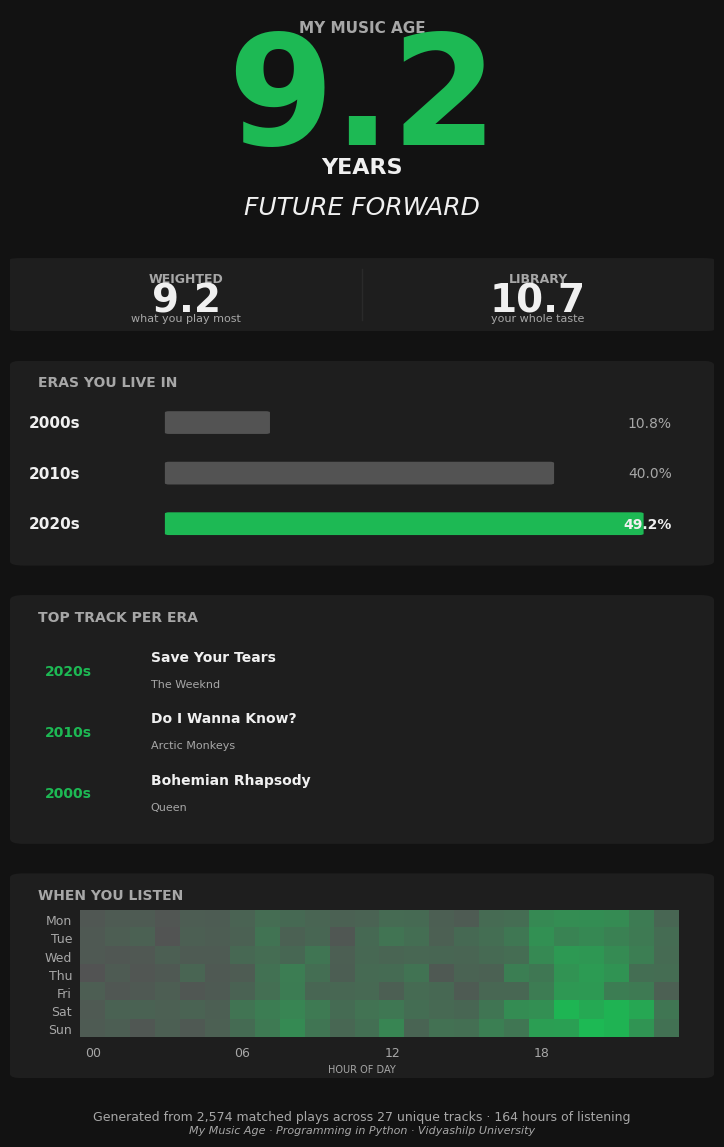


Saved to my_music_age_poster.png


In [3]:
from wrapped_poster import render_poster
import matplotlib.pyplot as plt

fig = render_poster(
    age=age,
    era_dist=dist,
    top_per_decade=top,
    listening_df=enriched,
    profile=profile,
    listening_stats=stats,
    out_path="my_music_age_poster.png",
)

plt.show()
print("\nSaved to my_music_age_poster.png")


## 3. Retuning the visual (optional)

Every design constant lives at the top of `wrapped_poster.py`. To try
a different palette, edit these and re-render:

```python
BG_COLOR        = "#121212"    # background
ACCENT_COLOR    = "#1DB954"    # highlight colour (bars, hero number)
TEXT_PRIMARY    = "#F0F0F0"    # main text
TEXT_SECONDARY  = "#A7A7A7"    # secondary labels
```

For example, to switch to a purple theme, change `ACCENT_COLOR` to
`"#8B5CF6"`. To go light-mode, swap `BG_COLOR` to `"#FAFAFA"`, text
colours to dark values, and bars to warm tones.


## 4. Next step — Stage 5

Stage 5 wraps everything into an interactive ipywidgets interface:

- File upload widget for your Spotify export
- Year-range slider to filter the analysis
- "Generate Report" button that re-runs the pipeline and re-renders
  the poster
- Download button for the resulting PNG

For the instructor's demo, Stage 5 is what you show live. The poster
from this stage is what you embed in slides and the GitHub README.
